Epoch 1/100


C:\WINDOWS\system32\myenv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.2087 - mae: 0.4148 - val_loss: 0.2307 - val_mae: 0.4053
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1368 - mae: 0.3167 - val_loss: 0.0976 - val_mae: 0.2604
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0636 - mae: 0.2060 - val_loss: 0.0636 - val_mae: 0.2127
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0542 - mae: 0.1876 - val_loss: 0.0641 - val_mae: 0.2226
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0406 - mae: 0.1659 - val_loss: 0.0704 - val_mae: 0.2330
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0451 - mae: 0.1714 - val_loss: 0.0598 - val_mae: 0.2175
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0444 - mae: 0.1749 - val_loss: 0.0567 - val_mae: 0.2130
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0330 - mae: 0.1427 - val_loss: 0.0557 - val_mae: 0.2125
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0366 -

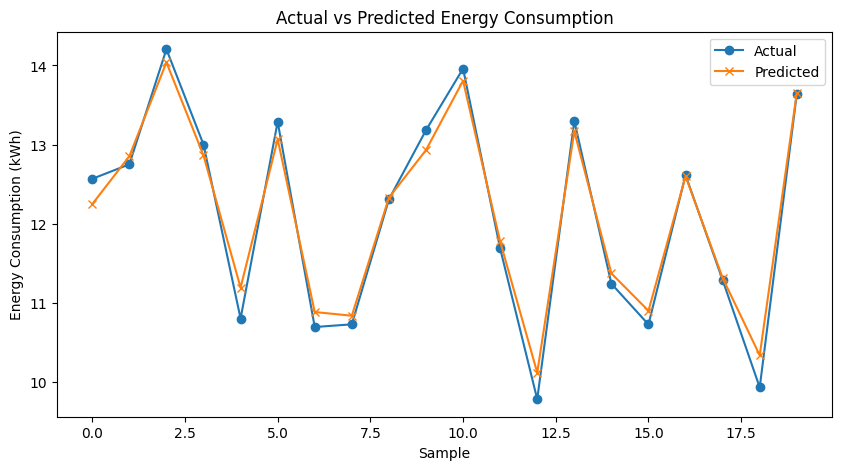

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
file_path = "C:/Users/Anarghya/OneDrive/Desktop/major project/energy_consumption_dataset in csv.csv" 
df = pd.read_csv(file_path)

# Encode categorical variable (Weather)
df["Weather"] = LabelEncoder().fit_transform(df["Weather"])

# Select features and target
X = df.drop(columns=["Total Energy Consumption (kWh)"])
y = df["Total Energy Consumption (kWh)"]

# Normalize data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Reshape for LSTM (samples, time steps, features)
X_lstm = np.reshape(X_scaled, (X_scaled.shape[0], 1, X_scaled.shape[1]))

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_lstm, y_scaled, test_size=0.2, random_state=42, shuffle=True)

# Define LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(1, X_train.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Train model with early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

# Predictions
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_inv = scaler_y.inverse_transform(y_test)

# Evaluation Metrics
mse = mean_squared_error(y_test_inv, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_inv, y_pred)

print(f"\nMSE: {mse:.4f}\nRMSE: {rmse:.4f}\nR²: {r2:.4f}")

# Plot Predictions vs Actual
plt.figure(figsize=(10, 5))
plt.plot(y_test_inv, label="Actual", marker='o')
plt.plot(y_pred, label="Predicted", marker='x')
plt.xlabel("Sample")
plt.ylabel("Energy Consumption (kWh)")
plt.legend()
plt.title("Actual vs Predicted Energy Consumption")
plt.show()


🔹 **Load Balancing Summary:**

⏳ Time Interval 1: Predicted Demand = 57 kWh
   ⚡ Grid: 50 kWh
   ⚡ Solar: 7 kWh
   ⚡ Unfulfilled Demand: 0 kWh
----------------------------------------
⏳ Time Interval 2: Predicted Demand = 81 kWh
   ⚡ Grid: 50 kWh
   ⚡ Solar: 30 kWh
   ⚡ Wind: 1 kWh
   ⚡ Unfulfilled Demand: 0 kWh
----------------------------------------
⏳ Time Interval 3: Predicted Demand = 44 kWh
   ⚡ Grid: 44 kWh
   ⚡ Unfulfilled Demand: 0 kWh
----------------------------------------
⏳ Time Interval 4: Predicted Demand = 55 kWh
   ⚡ Grid: 50 kWh
   ⚡ Solar: 5 kWh
   ⚡ Unfulfilled Demand: 0 kWh
----------------------------------------
⏳ Time Interval 5: Predicted Demand = 45 kWh
   ⚡ Grid: 45 kWh
   ⚡ Unfulfilled Demand: 0 kWh
----------------------------------------
⏳ Time Interval 6: Predicted Demand = 51 kWh
   ⚡ Grid: 50 kWh
   ⚡ Solar: 1 kWh
   ⚡ Unfulfilled Demand: 0 kWh
----------------------------------------
⏳ Time Interval 7: Predicted Demand = 73 kWh
   ⚡ Grid: 50 kWh
   ⚡ 

<Figure size 1200x600 with 0 Axes>

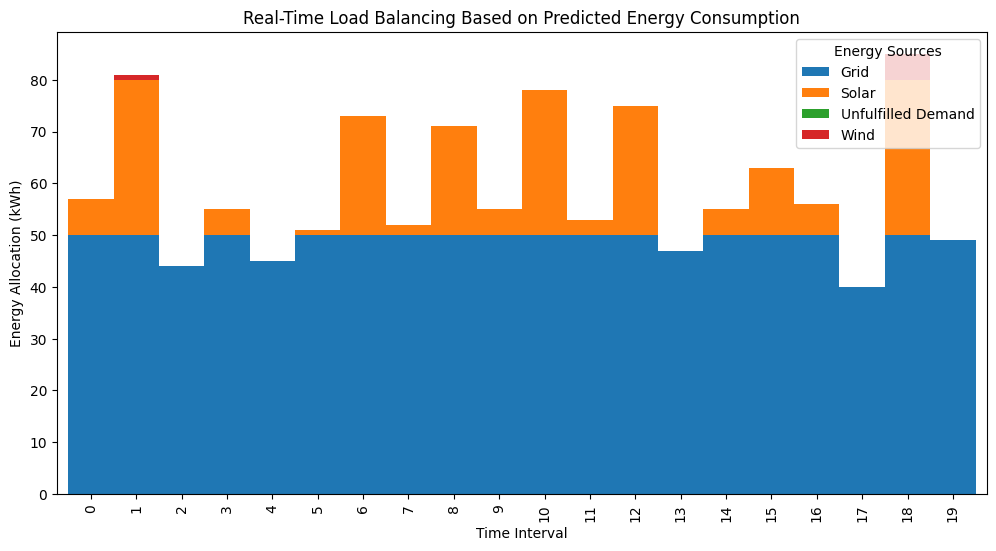

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Define available energy sources and capacities (in kWh)
energy_sources = {
    "Grid": 50,   # Max capacity from the main grid
    "Solar": 30,  # Max solar capacity
    "Wind": 20,   # Max wind capacity
    "Battery": 10  # Battery storage capacity
}

# Ensure y_pred is available from the previous cell
try:
    y_pred  # Check if y_pred exists
except NameError:
    print("⚠️ No previous prediction found. Generating random demand values for testing.")
    y_pred = np.random.randint(40, 90, size=20)  # Simulated demand

num_samples = len(y_pred)

# Load balancing function
def allocate_load(predicted_demand, sources):
    allocation = {}
    remaining_demand = predicted_demand

    for source, capacity in sources.items():
        if remaining_demand > capacity:
            allocation[source] = capacity
            remaining_demand -= capacity
        else:
            allocation[source] = remaining_demand
            remaining_demand = 0
            break  # Stop allocation once demand is met

    # If demand exceeds all sources combined
    allocation["Unfulfilled Demand"] = max(0, remaining_demand)

    return allocation

# Allocate energy sources for each time interval
allocations = [allocate_load(y_pred[i], energy_sources) for i in range(num_samples)]

# Convert to DataFrame for better visualization
allocation_df = pd.DataFrame(allocations)

# Real-Time Display of Load Balancing
print("\n🔹 **Load Balancing Summary:**\n")
for i in range(num_samples):
    print(f"⏳ Time Interval {i+1}: Predicted Demand = {y_pred[i]} kWh")
    for source, value in allocations[i].items():
        print(f"   ⚡ {source}: {value} kWh")
    print("-" * 40)
    time.sleep(0.5)  # Small delay for real-time effect

# Plot the Load Balancing over Time
plt.figure(figsize=(12, 6))
allocation_df.plot(kind="bar", stacked=True, figsize=(12, 6), width=1)
plt.xlabel("Time Interval")
plt.ylabel("Energy Allocation (kWh)")
plt.title("Real-Time Load Balancing Based on Predicted Energy Consumption")
plt.legend(title="Energy Sources")
plt.show()


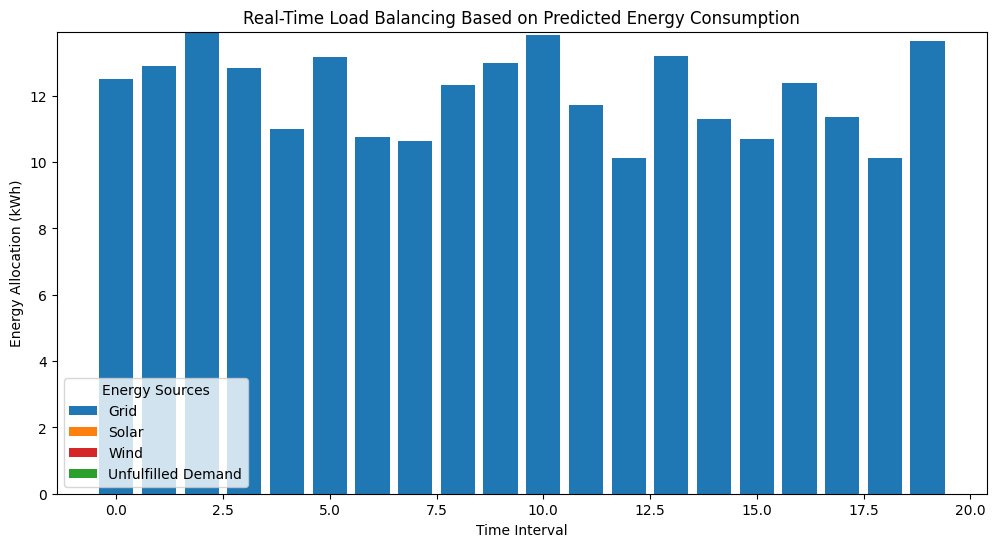


🔹 **Load Balancing Summary:**

⏳ Time Interval 1: Predicted Demand = 12.51 kWh
   ⚡ Grid: 12.51 kWh
   ⚡ Solar: 0.00 kWh
   ⚡ Wind: 0.00 kWh
   ⚡ Unfulfilled Demand: 0.00 kWh
----------------------------------------

⏳ Time Interval 2: Predicted Demand = 12.89 kWh
   ⚡ Grid: 12.89 kWh
   ⚡ Solar: 0.00 kWh
   ⚡ Wind: 0.00 kWh
   ⚡ Unfulfilled Demand: 0.00 kWh
----------------------------------------

⏳ Time Interval 3: Predicted Demand = 13.93 kWh
   ⚡ Grid: 13.93 kWh
   ⚡ Solar: 0.00 kWh
   ⚡ Wind: 0.00 kWh
   ⚡ Unfulfilled Demand: 0.00 kWh
----------------------------------------

⏳ Time Interval 4: Predicted Demand = 12.85 kWh
   ⚡ Grid: 12.85 kWh
   ⚡ Solar: 0.00 kWh
   ⚡ Wind: 0.00 kWh
   ⚡ Unfulfilled Demand: 0.00 kWh
----------------------------------------

⏳ Time Interval 5: Predicted Demand = 11.01 kWh
   ⚡ Grid: 11.01 kWh
   ⚡ Solar: 0.00 kWh
   ⚡ Wind: 0.00 kWh
   ⚡ Unfulfilled Demand: 0.00 kWh
----------------------------------------

⏳ Time Interval 6: Predicted Demand = 

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated real-time energy prediction (from the previous cell)
y_pred = np.array([
    [12.510492], [12.885241], [13.93384], [12.850216], [11.006291],
    [13.176416], [10.752556], [10.625749], [12.32503], [13.002061],
    [13.830391], [11.7266655], [10.129124], [13.215214], [11.3106165],
    [10.707023], [12.3878355], [11.367642], [10.129772], [13.643258]
]).flatten()  # Ensure it's a 1D array

# Energy source constraints (maximum supply per time interval)
GRID_MAX = 50  # kWh
SOLAR_MAX = 30  # kWh
WIND_MAX = 5    # kWh

# Storage for allocations
grid_supply = []
solar_supply = []
wind_supply = []
unfulfilled_demand = []

# Load balancing logic
for demand in y_pred:
    grid_alloc = min(demand, GRID_MAX)
    remaining_demand = demand - grid_alloc
    
    solar_alloc = min(remaining_demand, SOLAR_MAX)
    remaining_demand -= solar_alloc
    
    wind_alloc = min(remaining_demand, WIND_MAX)
    remaining_demand -= wind_alloc
    
    grid_supply.append(grid_alloc)
    solar_supply.append(solar_alloc)
    wind_supply.append(wind_alloc)
    unfulfilled_demand.append(remaining_demand)

# Convert lists to numpy arrays for plotting
grid_supply = np.array(grid_supply)
solar_supply = np.array(solar_supply)
wind_supply = np.array(wind_supply)
unfulfilled_demand = np.array(unfulfilled_demand)

# Plot the energy allocation
fig, ax = plt.subplots(figsize=(12, 6))
time_intervals = np.arange(len(y_pred))

ax.bar(time_intervals, grid_supply, label='Grid', color='tab:blue')
ax.bar(time_intervals, solar_supply, bottom=grid_supply, label='Solar', color='tab:orange')
ax.bar(time_intervals, wind_supply, bottom=grid_supply + solar_supply, label='Wind', color='tab:red')
ax.bar(time_intervals, unfulfilled_demand, bottom=grid_supply + solar_supply + wind_supply,
       label='Unfulfilled Demand', color='tab:green')

ax.set_xlabel("Time Interval")
ax.set_ylabel("Energy Allocation (kWh)")
ax.set_title("Real-Time Load Balancing Based on Predicted Energy Consumption")
ax.legend(title="Energy Sources")

plt.show()

# Print load balancing summary
print("\n🔹 **Load Balancing Summary:**")
for i, demand in enumerate(y_pred):
    print(f"\n⏳ Time Interval {i + 1}: Predicted Demand = {demand:.2f} kWh")
    print(f"   ⚡ Grid: {grid_supply[i]:.2f} kWh")
    print(f"   ⚡ Solar: {solar_supply[i]:.2f} kWh")
    print(f"   ⚡ Wind: {wind_supply[i]:.2f} kWh")
    print(f"   ⚡ Unfulfilled Demand: {unfulfilled_demand[i]:.2f} kWh")
    print("----------------------------------------")



⏳ Time Interval 1: Predicted Demand = 12.51 kWh
   ⚡ Grid: 12.51 kWh
   ☀️ Solar: 0.00 kWh
   🌬️ Wind: 0.00 kWh
   ❌ Unfulfilled Demand: 0.00 kWh
   ✅ All Appliances ON

⏳ Time Interval 2: Predicted Demand = 12.89 kWh
   ⚡ Grid: 12.89 kWh
   ☀️ Solar: 0.00 kWh
   🌬️ Wind: 0.00 kWh
   ❌ Unfulfilled Demand: 0.00 kWh
   ✅ All Appliances ON

⏳ Time Interval 3: Predicted Demand = 13.93 kWh
   ⚡ Grid: 13.93 kWh
   ☀️ Solar: 0.00 kWh
   🌬️ Wind: 0.00 kWh
   ❌ Unfulfilled Demand: 0.00 kWh
   ✅ All Appliances ON

⏳ Time Interval 4: Predicted Demand = 12.85 kWh
   ⚡ Grid: 12.85 kWh
   ☀️ Solar: 0.00 kWh
   🌬️ Wind: 0.00 kWh
   ❌ Unfulfilled Demand: 0.00 kWh
   ✅ All Appliances ON

⏳ Time Interval 5: Predicted Demand = 11.01 kWh
   ⚡ Grid: 11.01 kWh
   ☀️ Solar: 0.00 kWh
   🌬️ Wind: 0.00 kWh
   ❌ Unfulfilled Demand: 0.00 kWh
   ✅ All Appliances ON

⏳ Time Interval 6: Predicted Demand = 13.18 kWh
   ⚡ Grid: 13.18 kWh
   ☀️ Solar: 0.00 kWh
   🌬️ Wind: 0.00 kWh
   ❌ Unfulfilled Demand: 0.00 kWh
   

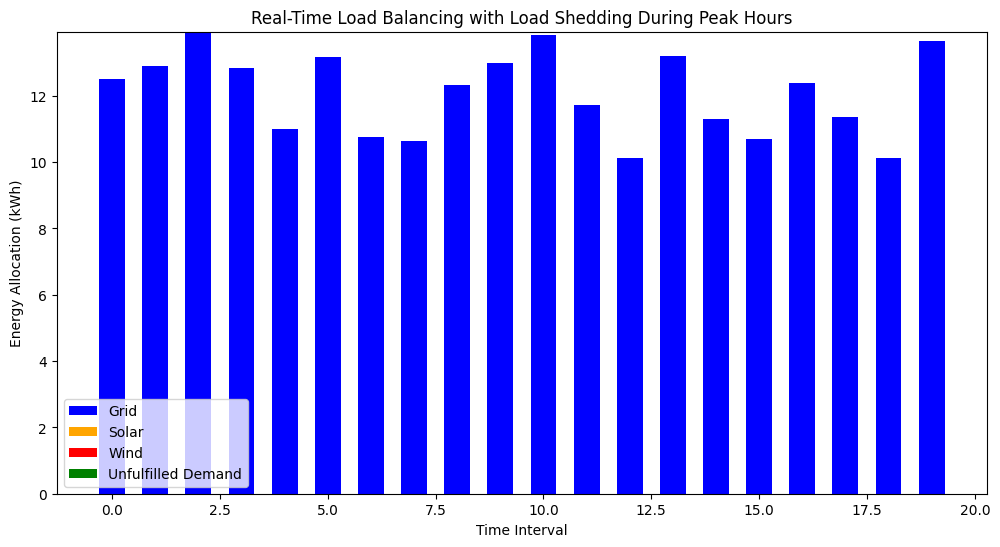

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated energy sources
GRID_CAPACITY = 15  # Max grid supply per time interval (kWh)
SOLAR_CAPACITY = 5  # Max solar energy supply per time interval (kWh)
WIND_CAPACITY = 2   # Max wind energy supply per time interval (kWh)

# Predicted energy demand from LSTM model (assumed from previous cell)
y_pred = np.array([
    12.510492, 12.885241, 13.93384, 12.850216, 11.006291,
    13.176416, 10.752556, 10.625749, 12.32503, 13.002061,
    13.830391, 11.7266655, 10.129124, 13.215214, 11.3106165,
    10.707023, 12.3878355, 11.367642, 10.129772, 13.643258
])

# Appliance Priority List
essential_appliances = ['Lights', 'Refrigerator', 'Router']
non_essential_appliances = ['Air Conditioner', 'Water Heater', 'TV']

# Load Balancing
grid_allocation = []
solar_allocation = []
wind_allocation = []
unfulfilled_demand = []
appliance_status = []  # Tracks which appliances were switched OFF

peak_threshold = 15  # Peak hour threshold for load shedding

for i, demand in enumerate(y_pred):
    grid_supply = min(GRID_CAPACITY, demand)
    remaining_demand = demand - grid_supply

    solar_supply = min(SOLAR_CAPACITY, remaining_demand)
    remaining_demand -= solar_supply

    wind_supply = min(WIND_CAPACITY, remaining_demand)
    remaining_demand -= wind_supply

    # If demand exceeds peak threshold, switch off non-essential appliances
    switched_off = []
    if demand > peak_threshold:
        switched_off = non_essential_appliances.copy()
    
    # Store allocations
    grid_allocation.append(grid_supply)
    solar_allocation.append(solar_supply)
    wind_allocation.append(wind_supply)
    unfulfilled_demand.append(max(0, remaining_demand))  # Any unmet demand
    appliance_status.append(switched_off)

# Print Load Balancing Summary
for i in range(len(y_pred)):
    print(f"\n⏳ Time Interval {i+1}: Predicted Demand = {y_pred[i]:.2f} kWh")
    print(f"   ⚡ Grid: {grid_allocation[i]:.2f} kWh")
    print(f"   ☀️ Solar: {solar_allocation[i]:.2f} kWh")
    print(f"   🌬️ Wind: {wind_allocation[i]:.2f} kWh")
    print(f"   ❌ Unfulfilled Demand: {unfulfilled_demand[i]:.2f} kWh")
    
    if appliance_status[i]:
        print(f"   🛑 Switched OFF Appliances: {', '.join(appliance_status[i])}")
    else:
        print(f"   ✅ All Appliances ON")

# Visualization
time_intervals = np.arange(len(y_pred))
width = 0.6  # Bar width

plt.figure(figsize=(12, 6))
plt.bar(time_intervals, grid_allocation, width, label="Grid", color='blue')
plt.bar(time_intervals, solar_allocation, width, bottom=grid_allocation, label="Solar", color='orange')
plt.bar(time_intervals, wind_allocation, width, bottom=np.array(grid_allocation) + np.array(solar_allocation), label="Wind", color='red')
plt.bar(time_intervals, unfulfilled_demand, width, bottom=np.array(grid_allocation) + np.array(solar_allocation) + np.array(wind_allocation), label="Unfulfilled Demand", color='green')

plt.xlabel("Time Interval")
plt.ylabel("Energy Allocation (kWh)")
plt.title("Real-Time Load Balancing with Load Shedding During Peak Hours")
plt.legend()
plt.show()